In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
from frouros.detectors.data_drift import MMDStreaming
from frouros.utils.kernels import rbf_kernel

import obsea

obsea.config.device = "cpu"

In [2]:
settings = obsea.utils.load_config("v3.1")
images_parent = obsea.datasets.images_path("v3.1")
transform = obsea.datasets.get_transform(settings["transform"])

In [3]:
in_channels = settings["image"]["n_channels"]
image_names = settings["camera_state"]["clean"]
image_paths = [images_parent / name for name in image_names]

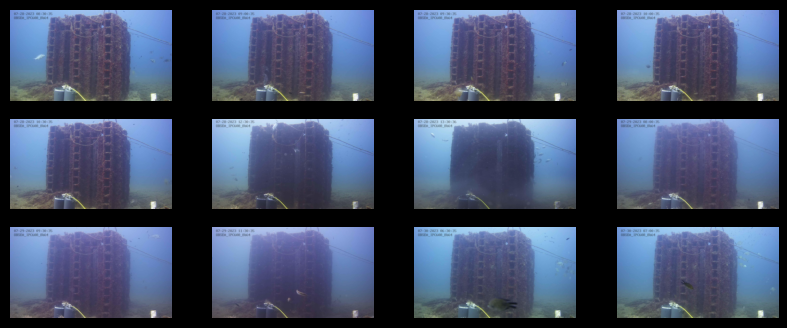

In [4]:
dataset = obsea.datasets.ImageDataset(image_paths, transform=transform)
fig, axes = plt.subplots(3, 4, figsize=(10, 4))
for image, ax in zip(dataset, axes.flatten()):
    img = image.permute(1, 2, 0).detach().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

In [5]:
with open("encoded/v3.1_autoencoder_clean.pt", "rb") as f:
    encodings_clean = torch.load(f).to("cpu")
print(f"Encodings shape: {encodings_clean.shape}")

Encodings shape: torch.Size([527, 200])


In [6]:
detector = MMDStreaming(window_size=12, kernel=partial(rbf_kernel, sigma=0.30))
detector

MMD(callbacks=[], data_type=NumericalData(output_type=<class 'numpy.float32'>), statistical_type=MultivariateData(im_check=<built-in function ge>))

In [7]:
_ = detector.fit(encodings_clean.numpy())
# Warm up the detector
for sample in encodings_clean[: detector.window_size]:
    result, _ = detector.update(sample.numpy())
    if result is not None:
        print(f"Distance: {result.distance}")

Distance: 0.0873500929690704


In [8]:
distances_clean = [detector.update(sample.cpu().numpy())[0] for sample in encodings_clean[:24]]
distances_clean = np.array(distances_clean)
max, min = distances_clean.max(), distances_clean.min()
print(f"Max clean: {max}, Min clean: {min}")
mean, std = distances_clean.mean(), distances_clean.std()
print(f"Mean clean: {mean}, Std clean: {std}")

Max clean: 0.09309763159374113, Min clean: 0.05697505520624916
Mean clean: 0.08322697357760316, Std clean: 0.0082990562175035


In [9]:
in_channels = settings["image"]["n_channels"]
image_names = settings["camera_state"]["dirty"]
image_paths = [images_parent / name for name in image_names]

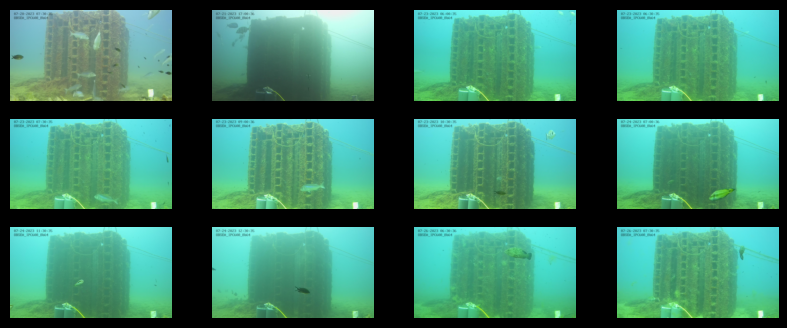

In [10]:
dataset = obsea.datasets.ImageDataset(image_paths, transform=transform)
fig, axes = plt.subplots(3, 4, figsize=(10, 4))
for image, ax in zip(dataset, axes.flatten()):
    img = image.permute(1, 2, 0).detach().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

In [11]:
with open("encoded/v3.1_autoencoder_dirty.pt", "rb") as f:
    encodings_dirty = torch.load(f).to("cpu")
print(f"Encodings shape: {encodings_dirty.shape}")

Encodings shape: torch.Size([12, 200])


In [12]:
for sample in encodings_dirty:
    result, _ = detector.update(sample.cpu().numpy())
    if result.distance <= (mean + 3 * std):
        print("No data drift detected, distance:", result.distance)
    elif result.distance <= (mean + 5 * std):
        print("Data drift warning, distance:", result.distance)
    else:
        print("Data drift detected, distance:", result.distance)

No data drift detected, distance: 0.05038947476618863
No data drift detected, distance: 0.03675958694301565
No data drift detected, distance: 0.029576085479971884
No data drift detected, distance: 0.045754065337808916
No data drift detected, distance: 0.06864525005565912
No data drift detected, distance: 0.09363326127363553
Data drift warning, distance: 0.12318130194185702
Data drift detected, distance: 0.1657215065538154
Data drift detected, distance: 0.21767477195522184
Data drift detected, distance: 0.27826470101932177
Data drift detected, distance: 0.36007794696887974
Data drift detected, distance: 0.45395747431712186
